### [Quantitative Finance Series: Predicting Stock Prices](https://python.plainenglish.io/quantitative-finance-series-predicting-stock-prices-with-python-and-monte-carlo-simulation-f8a7969a9728)

**Monte Carlo Simulation** is a way to understand the impact of risk and uncertainty in a prediction model. It doesn’t give us a single, definitive answer. It runs a large number of random trials to calculate a range of possible outcomes and their probabilities.

#### **Geometric Brownian Motion (GBM)**

GBM describes a path where the change at any point is random. It has two main components:

- **Drift (μ)**: This represents the average rate of return of the stock over a period. Think of it as the general direction the stock price is heading, based on its historical performance.
- **Volatility (σ)**: This represents the degree of variation in the stock's returns. A high-volatility stock will have much wilder (less predictable) price swings than a low-volatility one.

$$S_t = S_{t-1} * e^{((μ — 0.5 * σ²) * Δt + σ * W_t)}$$

Where:

- $S_t$ is the stock price at time t.
- $S_{t-1}$ is the stock price at the $'t-1'$.
- $e$ is the exponential constant.
- $μ$ (mu) is the drift.
- $σ$ (sigma) is the volatility.
- $Δt$ (delta t) is the time step (e.g., one day).
- $W_t$ is the "random" part, a random variable drawn from a normal distribution with a mean of 0 and a standard deviation of sqrt($Δt$).

In [1]:
!pip install -q numpy pandas yfinance matplotlib

##### **Fetching Historical Stock Data**

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

# Define the stock ticker and data source
ticker = 'AAPL'

# Define the start and end dates for our historical data
start_date = datetime(2015, 1, 1)
end_date = datetime(2024, 12, 31)

# Fetch the data
stock_data = yf.download(ticker, start=start_date, end=end_date)

# We only need the 'Adj Close' price
adj_close = stock_data['Close']

print("Last 5 days of historical data:")
adj_close.tail()

[*********************100%***********************]  1 of 1 completed

Last 5 days of historical data:


Ticker,AAPL
Date,
2024-12-23,254.120697
2024-12-24,257.037476
2024-12-26,257.853760
2024-12-27,254.439224
2024-12-30,251.064499


##### **Calculating Drift and Volatility**

In [3]:
# Calculate daily logarithmic returns
log_returns = np.log(1 + adj_close.pct_change())
log_returns.dropna(inplace=True)

# Calculate drift (average daily return)
mu = float(log_returns.mean())
print(f"Drift (μ): {mu:.6f}")

# Calculate volatility (standard deviation of daily returns)
sigma = float(log_returns.std())
print(f"Volatility (σ): {sigma:.6f}")

Drift (μ): 0.000930
Volatility (σ): 0.017934


##### **Building the Monte Carlo Simulation Engine**

In [4]:
def monte_carlo_simulation(start_price, days, mu, sigma):
    dt = 1 # Time step is one day

    price_path = np.zeros(days)
    price_path[0] = start_price

    # Generate random values for each day
    shocks = np.random.normal(loc=mu, scale=sigma, size=days)

    for t in range(1, days):
    # Apply the GBM formula
      price_path[t] = price_path[t-1] * np.exp(shocks[t-1])

    return price_path

##### **Running the Simulation Multiple Times**

In [5]:
# Simulation parameters
num_simulations = 1000
simulation_days = 252 # One trading year

# Get the last known stock price
last_price = float(adj_close.iloc[-1])

# Store all simulation results
all_simulations = np.zeros((num_simulations, simulation_days))

# Run the simulation
for i in range(num_simulations):
    all_simulations[i, :] = monte_carlo_simulation(last_price, simulation_days, mu, sigma)

##### **Visualizing and Analyzing the Results**

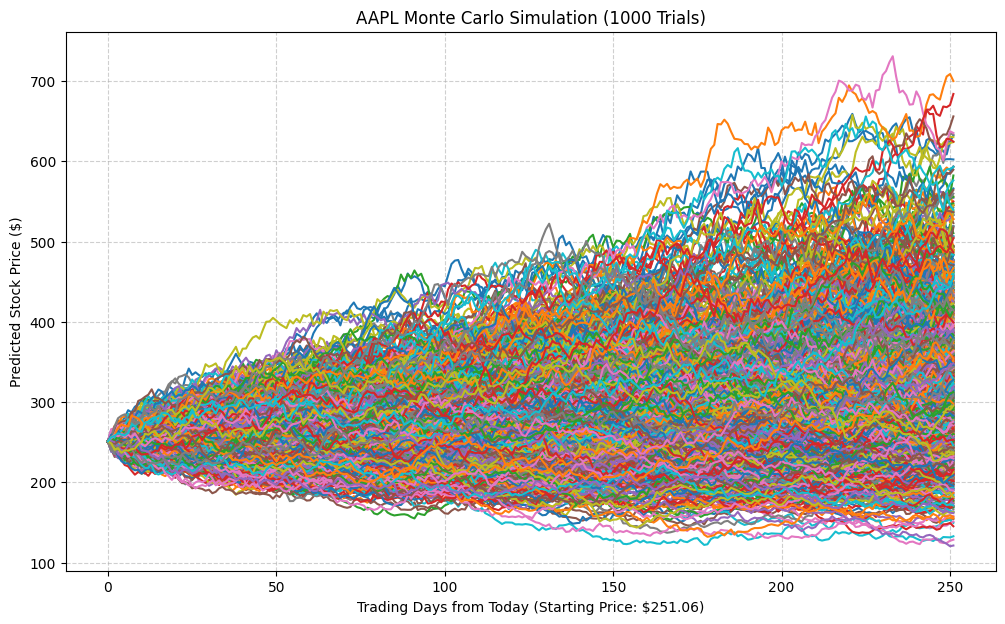

In [6]:
# Plot the simulation results
plt.figure(figsize=(12, 7))
plt.plot(all_simulations.T) # Transpose for plotting
plt.title(f'{ticker} Monte Carlo Simulation ({num_simulations} Trials)')
plt.xlabel(f'Trading Days from Today (Starting Price: ${last_price:.2f})')
plt.ylabel('Predicted Stock Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

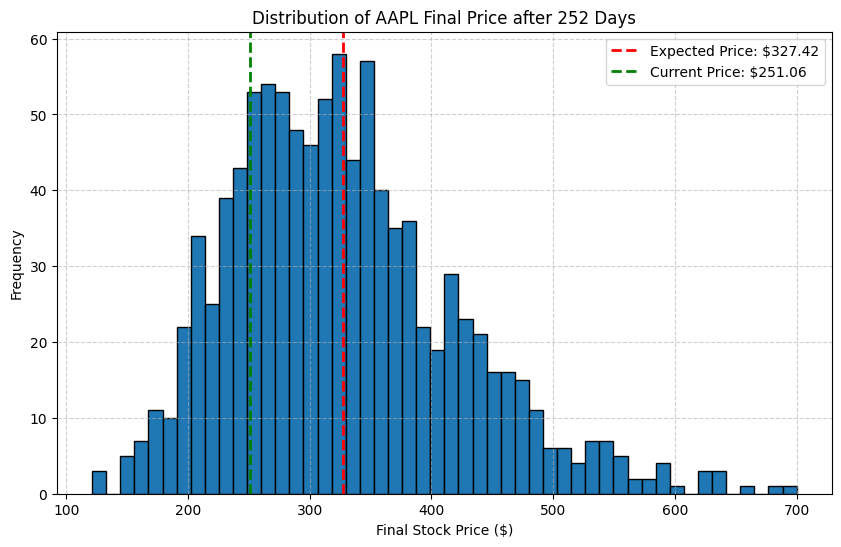

In [7]:
# Get the final prices from each simulation
final_prices = all_simulations[:, -1]

# Plot the distribution of final prices
plt.figure(figsize=(10, 6))
plt.hist(final_prices, bins=50, edgecolor='black')
plt.title(f'Distribution of {ticker} Final Price after {simulation_days} Days')
plt.xlabel('Final Stock Price ($)')
plt.ylabel('Frequency')
plt.axvline(final_prices.mean(), color='r', linestyle='dashed', linewidth=2, label=f'Expected Price: ${final_prices.mean():.2f}')
plt.axvline(last_price, color='g', linestyle='dashed', linewidth=2, label=f'Current Price: ${last_price:.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
# Print some key statistics
print("Simulation Analysis:")
print(f"Expected Stock Price after {simulation_days} days: ${final_prices.mean():.2f}")
print(f"Median Stock Price: ${np.median(final_prices):.2f}")
print(f"5% Quantile (Value at Risk): ${np.percentile(final_prices, 5):.2f}")
print(f"95% Quantile: ${np.percentile(final_prices, 95):.2f}")

Simulation Analysis:
Expected Stock Price after 252 days: $327.42
Median Stock Price: $317.46
5% Quantile (Value at Risk): $199.83
95% Quantile: $493.38
